<a href="https://colab.research.google.com/github/Nafiaakter/CSE707/blob/main/Task_2_img.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark
!pip install matplotlib





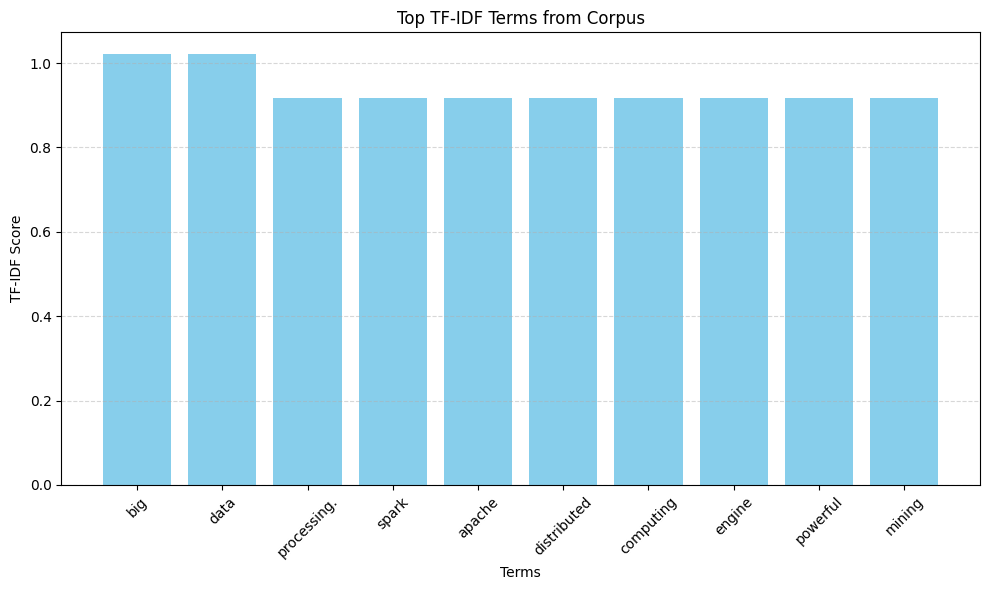

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Step 1: Start Spark
spark = SparkSession.builder.appName("TFIDF-BarPlot").getOrCreate()

# Step 2: Input text data
data = [
    (0, "Apache Spark is a powerful distributed computing engine for big data processing."),
    (1, "Big data text mining needs scalable and efficient frameworks."),
    (2, "TF-IDF is commonly used for feature extraction in text classification."),
    (3, "Machine learning models need high-quality features from text data."),
]
df = spark.createDataFrame(data, ["id", "text"])

# Step 3: Preprocess
tokenizer = Tokenizer(inputCol="text", outputCol="words_token")
remover = StopWordsRemover(inputCol="words_token", outputCol="words_clean")
vectorizer = CountVectorizer(inputCol="words_clean", outputCol="rawFeatures")
idf = IDF(inputCol="rawFeatures", outputCol="features")

# Step 4: Create pipeline
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, idf])
model = pipeline.fit(df)
result = model.transform(df)

# Step 5: Get vocab and TF-IDF scores
vocab = model.stages[2].vocabulary  # CountVectorizer vocab
word_scores = Counter()

for row in result.select("features").collect():
    sparse_vector = row["features"]
    for idx, score in zip(sparse_vector.indices, sparse_vector.values):
        word = vocab[idx]
        word_scores[word] += score

# Step 6: Top 10 words
top_terms = word_scores.most_common(10)
if not top_terms:
    print("No top terms found.")
else:
    words, scores = zip(*top_terms)

    # Step 7: Plot
    plt.figure(figsize=(10, 6))
    plt.bar(words, scores, color='skyblue')
    plt.title("Top TF-IDF Terms from Corpus")
    plt.xlabel("Terms")
    plt.ylabel("TF-IDF Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


In [ ]:
plt.savefig("word_frequency_chart.png")
